# Project: A/B Testing Analysis


# Business Problem
A company launched a new website design and wants to know:


> Does the new design increase user conversion rate?

Two groups exist:
| Group       | Meaning    |
| ----------- | ---------- |
| Control (A) | Old design |
| Test (B)    | New design |

We will analyze whether the new design improves conversions.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

Create Sample Dataset:

In [9]:
np.random.seed(42)

n = 1000
data = pd.DataFrame({
    "group": np.random.choice(["Control", "Test"], size =n),
    "converted": np.random.binomial(1, 0.10, size = n)
})
data.head()

,group,converted
0,Control,0
1,Test,0
2,Control,0
3,Control,0
4,Control,0


In [10]:
# Check Structure:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   group      1000 non-null   object
 1   converted  1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [11]:
# Check number of users in each group:
data["group"].value_counts()

,count
group,
Test,510
Control,490


Calculate Conversion Rates:


In [13]:
conversion_rate = data.groupby("group")["converted"].mean()
conversion_rate

,converted
group,
Control,0.093878
Test,0.101961


Visulaize Conversion Rates:

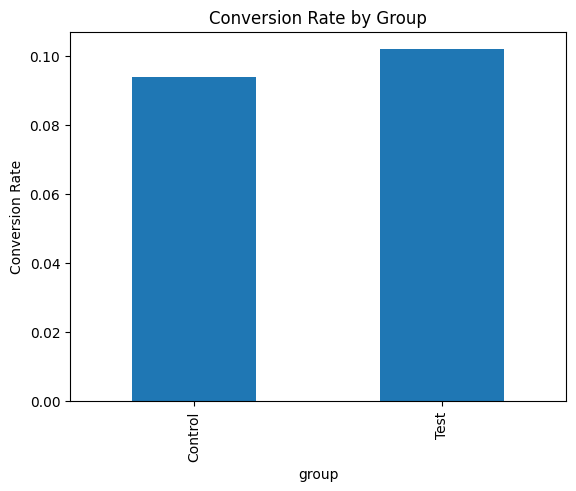

In [14]:
conversion_rate.plot(kind = "bar")

plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

In [15]:
# Save image for GitHub
plt.savefig("conversion_rate.png")

<Figure size 640x480 with 0 Axes>

Perform Statistical Test:

In [18]:
control = data[data["group"] == "Control"]["converted"]
test = data[data["group"] == "Test"]["converted"]

t_stat, p_value = ttest_ind(control,test)
print("T-statistics:", t_stat)
print("P-value:", p_value)

T-statistics: -0.4293953327496573
P-value: 0.6677282320769939


-> p-value = 0.67

Hypothesis Testing:


*   Null Hypothesis ($H_0$): The new website design does not change the conversion rate.
*   Alternative Hypothesis ($H_1$): The new website design improves the conversion rate





*   p-value = 0.67
*   Significance level ($α$)=0.05\
-> p-value > $α$. Fail to reject the null hypothesis.



Conclusion:\
There is no statistically significant evidence that the new design improves conversions.

**Business Insights**



1.   The experiemnet showed a small difference in conversion rate between the control and test groups.
2.   Statistical testing resulted in a p-value of 0.67, indicating the difference was not statistically significnat.



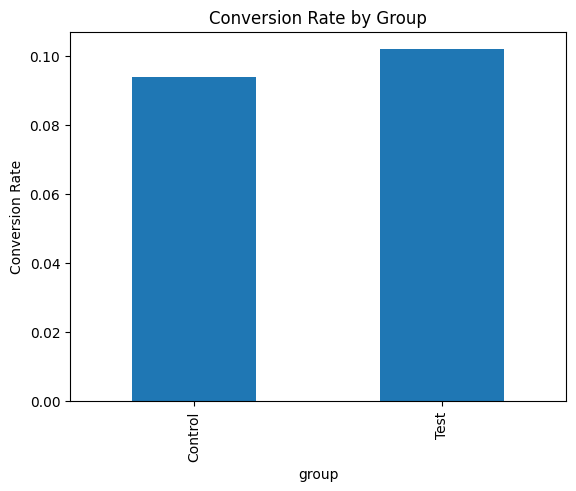

In [20]:
conversion_rate.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")

plt.savefig("conversion_rate.png")

plt.show()